In [30]:
from pathlib import Path
import pandas as pd
from scipy.stats import ttest_ind, boxcox, shapiro
import numpy as np
from matplotlib import pyplot as plt

import scienceplots
plt.style.use(['science', 'ieee', 'grid'])
plt.rcParams.update({"font.size": 12})
plt.rcParams.update({"mathtext.default": "regular"})

%load_ext autoreload
%autoreload 2

In [15]:
data_folder = Path("/Users/magnus/repos/ml-footprint-pred/paper1/")

In [3]:
def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set_xlim(0.5, len(labels) + 0.5)

def plot_two_violions(desc, labels, dataset):
    cm = 1 / 2.54
    fig, ax = plt.subplots(figsize=(18 * cm, 10 * cm), dpi=300)
    pos = np.arange(0, 2)
    v1 = ax.violinplot(dataset=dataset, positions=pos+1, widths=0.5, showextrema=False, showmedians=True)
    
    med1 = v1['cmedians']
    med1.set_color('black')
    med1.set_linestyle('-')
    
    ax.set_ylabel(desc["y-axis"])
    ax.set_ylim(0, 1.0)
    set_axis_style(ax, labels)
    plt.show()

In [16]:
b2b_resnet_energy = np.loadtxt(data_folder / "b2b_results/data/b2b_losses_fp:Resnet-g2cyy7rt_shape:Energy2.csv")

In [17]:
trues = np.loadtxt("ys.csv", delimiter=",")
preds = np.loadtxt("mean_predictions.csv", delimiter=",")

In [18]:
from scipy.spatial.distance import cdist
modhaussdorff = []

for true, pred in zip(trues, preds):
    
    x = np.arange(0, len(preds) / 10, 0.1)
    
    dist = cdist(list(zip(x, true)), list(zip(x, pred)))
    modhaussdorff.append((np.median(np.min(dist, axis=1))))

In [19]:
np.array(modhaussdorff).shape

(56,)

In [27]:
b2b_resnet_energy = np.loadtxt(data_folder / "b2b_results/data/b2b_losses_fp:Resnet-g2cyy7rt_shape:Energy2.csv")
b2b_perfect_energy = np.loadtxt(data_folder / "b2b_results/data/b2b_losses_fp:Perfect_shape:Energy2.csv")

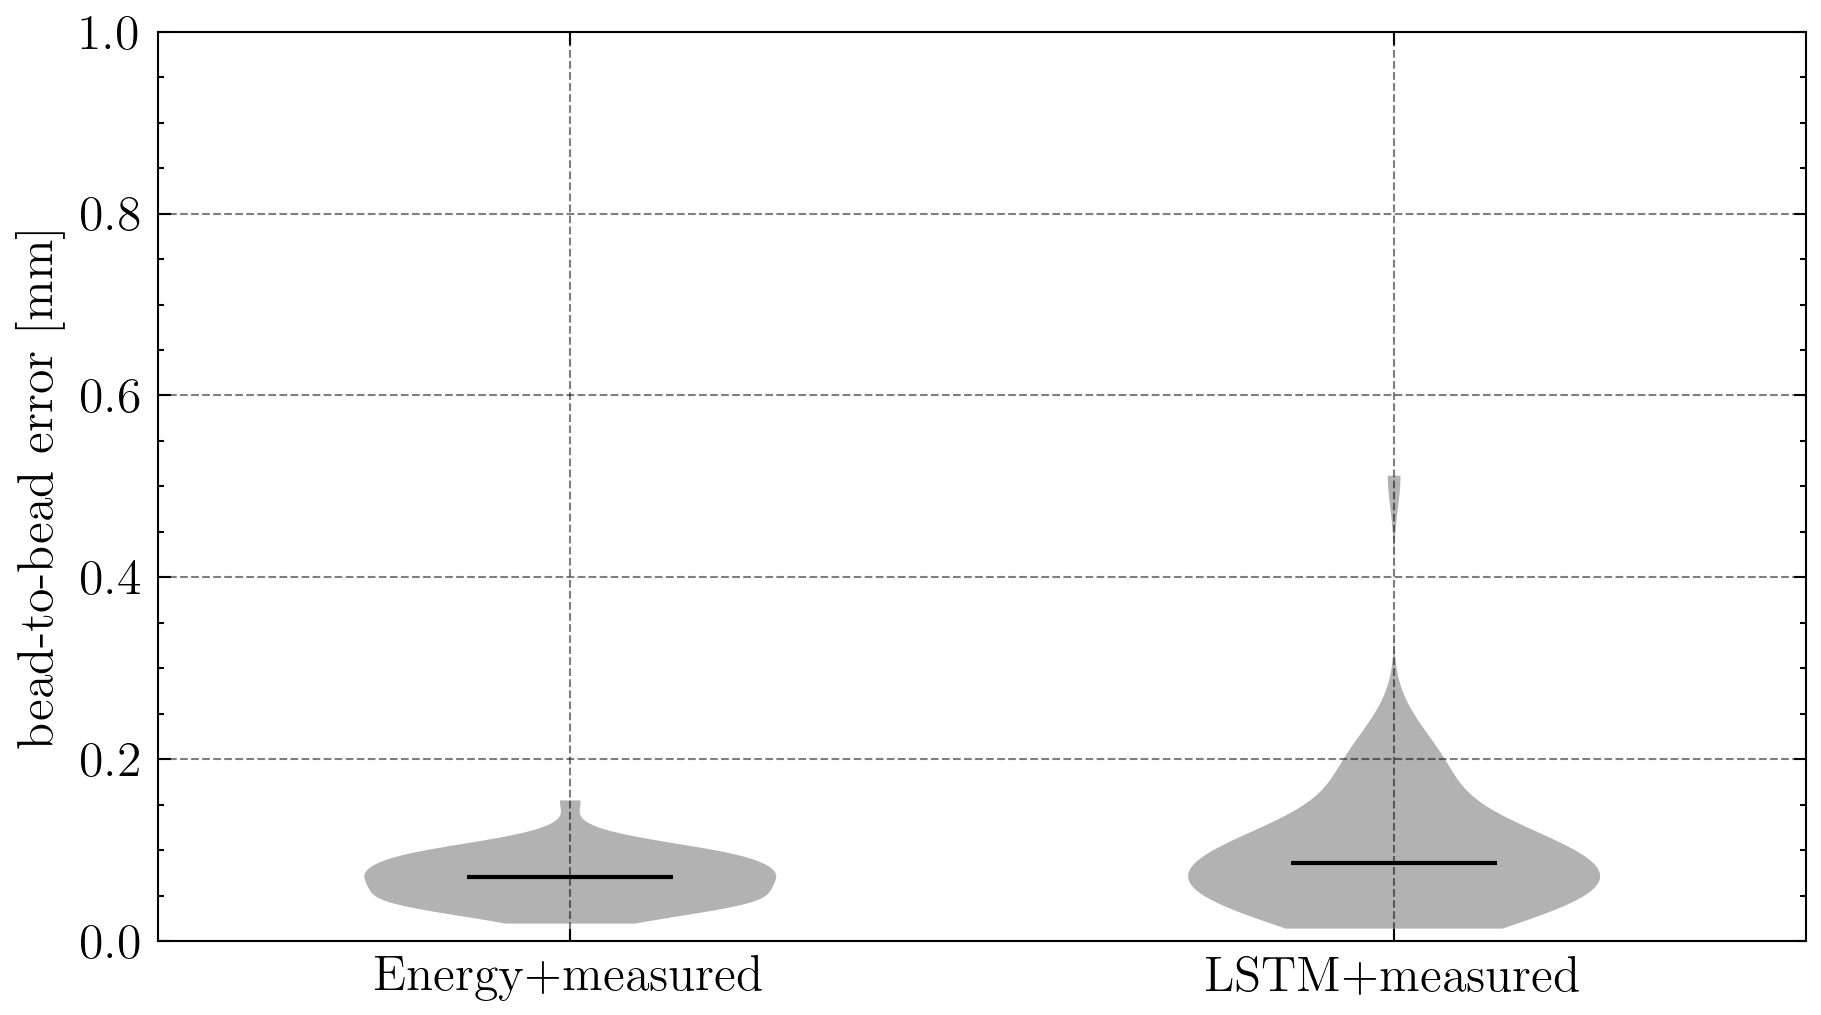

In [32]:
desc = {
    "title": "",
    "x-axis": "",
    "y-axis": "bead-to-bead error $[\mathrm{mm}]$"
}

labels = ["Energy+measured", "LSTM+measured"]

plot_two_violions(desc, labels, [np.array(b2b_perfect_energy), np.array(modhaussdorff)])

In [31]:
# Generate non-normal data for the example
np.random.seed(42)
sample_1 = modhaussdorff
sample_2 = b2b_perfect_energy

# Apply Box-Cox transformation
sample_1_transformed, _ = boxcox(sample_1)
sample_2_transformed, _ = boxcox(sample_2)

# Check normality using Shapiro-Wilk test
_, p_value_1 = shapiro(sample_1_transformed)
_, p_value_2 = shapiro(sample_2_transformed)

if p_value_1 > 0.05 and p_value_2 > 0.05:
    print("Both transformed samples appear to be normally distributed.")
else:
    print("One or both transformed samples do not appear to be normally distributed.")

# Conduct the t-test for independent samples on transformed data
t_stat, p_value = ttest_ind(sample_1_transformed, sample_2_transformed)

# Choose a significance level
alpha = 0.05

# Make a decision based on the p-value
if p_value < alpha:
    print(f"Reject the null hypothesis (p-value = {p_value:.4f})")
    print("The means of the two transformed samples are statistically different.")
else:
    print(f"Fail to reject the null hypothesis (p-value = {p_value:.4f})")
    print("The means of the two transformed samples are not statistically different.")

Both transformed samples appear to be normally distributed.
Reject the null hypothesis (p-value = 0.0000)
The means of the two transformed samples are statistically different.
